# 03 · The State Model

**Purpose.** Predict, for any account-trip at any price, the probability distribution across behavioral states. The simulation multiplies these probabilities by revenue outcomes, so a probability that is merely *ranked* correctly is not enough — it has to be numerically right, and it has to move correctly when the price moves.

**Architecture.** Two stages, separated on purpose.

| Stage | Method | Handles |
|---|---|---|
| 1 | Gradient-boosted trees on non-price features | Customer heterogeneity — who this account is |
| 2 | Multinomial logit with stage 1 as a **fixed offset** | The price dimension only |

A single tree model on all features including price fails three ways here: it cannot interpolate between the discrete price levels in the data, its price response is whatever the trees happened to fit rather than an identified effect, and it produces local reversals where a higher price looks *better* for retention. Price in a parametric term with a pinned offset fixes all three.

**What the plan requires**

| Requirement | Why it cannot be skipped |
|---|---|
| Labels reconstructed from observables | The five states are unobserved in production |
| Split by time, never at random | A random split leaks the future into the past |
| Price identified, not just fitted | Price was not randomly assigned |
| Monotone, smooth price response | Simulation curves must be defensible and continuous |
| Calibrated probabilities | `Σ P(state) × revenue(state)` consumes quantities, not rankings |
| Response that transfers | Applying a new price to the whole book assumes it does |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

DATA = Path("data/synthetic")


def load(name):
    pq, csv = DATA / f"{name}.parquet", DATA / f"{name}.csv"
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"{name} not found in {DATA.resolve()} — run notebook 01 first.")


accounts = load("accounts")
macro = load("macro")
trips = load("trips").merge(accounts, on="account_id", how="left")
trips = trips.merge(macro[["month", "macro_index"]], on="month", how="left")
ground_truth = load("ground_truth")     # §9 only, never a feature

CLASSES = ["no_purchase", "reduces", "unchanged", "increases"]
IDX = {c: i for i, c in enumerate(CLASSES)}

# --- log_loss column-order guard -------------------------------------------
# sklearn.log_loss binarises `labels` in SORTED order regardless of the order
# passed, so a probability matrix in CLASSES order is silently read permuted.
# Every log loss below goes through this helper. The first version of this
# notebook did not, and reported numbers three times worse than reality.
SORTED = sorted(CLASSES)
PERM = [CLASSES.index(c) for c in SORTED]


def LL(yv, P):
    return log_loss(yv, P[:, PERM], labels=SORTED)


def softmax(eta):
    e = np.exp(eta - eta.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 9})
INK, ACCENT, MUTED = "#201e1d", "#1c4ed8", "#9a9694"

print(f"{len(trips):,} trips · {trips.account_id.nunique():,} accounts · {trips.month.nunique()} months")

94,440 trips · 29,312 accounts · 24 months


---
## 1 · Reconstruct the labels

The rule notebook 02 selected: **coverage ratio below 0.70**. It won on F1 and has the higher recall of the two front-runners — under-labelling a real reduction understates price damage, the more expensive error given the decision.

`substitutes` and `leaves` stay pooled as `no_purchase`; they are indistinguishable at trip level. Departure is handled at account level in §10.

In [2]:
DAY_THRESH = 0.70


def reconstruct_label(df, day_thresh=DAY_THRESH):
    ratio = df["days_bought"] / df["days_traveled"]
    lines = df["lines_active"] / df["lines_traveling"].clip(lower=1)
    y = pd.Series("unchanged", index=df.index, dtype=object)
    y[ratio > 1.0] = "increases"
    y[(ratio < day_thresh) | (lines < 0.999)] = "reduces"
    y[df["days_bought"] == 0] = "no_purchase"
    return y


trips["y"] = reconstruct_label(trips)
truth_pooled = trips["state"].replace({"substitutes": "no_purchase", "leaves": "no_purchase"})
y = trips["y"].to_numpy()
yi = np.array([IDX[v] for v in y])

print(trips["y"].value_counts(normalize=True).round(4).to_string())
print(f"\nAgreement with the true state: {(trips.y == truth_pooled).mean():.1%}")

base = trips["y"].value_counts(normalize=True).reindex(CLASSES).to_numpy()
BASE_LL = -(base * np.log(base)).sum()
print(f"\nBenchmark — log loss of a constant base-rate predictor: {BASE_LL:.4f}")
print("Any model above this is actively harmful, whatever its other metrics say.")

y
unchanged      0.7262
reduces        0.1147
no_purchase    0.0948
increases      0.0643

Agreement with the true state: 95.1%

Benchmark — log loss of a constant base-rate predictor: 0.8804
Any model above this is actively harmful, whatever its other metrics say.


---
## 2 · Features, and two audits

**Leakage audit.** Features must be knowable before the purchase decision:

| Excluded | Why |
|---|---|
| `days_bought`, `lines_active` | The decision itself — these *define* the label |
| `pass_revenue`, `account_lost` | Downstream of the decision |
| `state` | The true label |
| `price_sensitivity`, `travel_propensity` | Latent truth, unobservable in production |

**Collinearity audit.** This one caught a real defect. `substitute_ease` is a *lookup from region* — a deterministic function of it. Any price interaction with `substitute_ease` is therefore collinear with the region dummies, and the fit splits the price effect between them arbitrarily. In the previous version that produced `log_price` = +3.2 alongside `lp × ease` = −4.5, a **net negative** price effect for high-ease regions, which is nonsense. The check below runs before modelling so it cannot happen silently. Given the audit's conclusion, `substitute_ease` is excluded from both stages: region dummies already carry the same information in stage 1, and it never appears as a stage-2 price interaction.

`prior_trips` uses an expanding window: for any trip, only trips in *earlier* months count.

In [3]:
# --- collinearity audit ---
ease_by_region = trips.groupby("region")["substitute_ease"].nunique()
print("Distinct substitute_ease values per region:")
print(ease_by_region.to_string())
DETERMINISTIC = bool((ease_by_region == 1).all())
print(f"\nsubstitute_ease is a deterministic function of region: {DETERMINISTIC}")
print("-> excluded from both stages: region dummies in stage 1 already carry the")
print("   same information, and it is never a stage-2 price interaction, where it")
print("   would split the price effect with the region dummies.")


def build_features(df):
    out = pd.DataFrame(index=df.index)
    out["is_business"] = df["is_business"].astype(int)
    out["lines_on_account"] = df["lines_on_account"]
    out["tenure_months"] = df["tenure_months"]
    out["premium"] = (df["plan_tier"] == "premium").astype(int)
    out["value_tier"] = (df["plan_tier"] == "value").astype(int)
    out["lines_traveling"] = df["lines_traveling"]
    out["days_traveled"] = df["days_traveled"]
    for r in ["europe", "latam", "apac", "canada"]:
        out[f"region_{r}"] = (df["region"] == r).astype(int)
    out["month_of_year"] = df["month"] % 12
    out["macro_index"] = df["macro_index"]
    return out


hist = trips[["account_id", "month"]].sort_values(["account_id", "month"])
cum = hist.groupby("account_id").cumcount()
same = hist.groupby(["account_id", "month"]).cumcount()
trips["prior_trips"] = (cum - same).reindex(trips.index).fillna(0).astype(int)
trips["log_price"] = np.log(trips["price_multiplier"])

X = build_features(trips)
X["prior_trips"] = trips["prior_trips"]

LEAKY = {"days_bought", "lines_active", "pass_revenue", "account_lost", "state",
         "price_sensitivity", "travel_propensity", "price_multiplier", "log_price"}
assert not (set(X.columns) & LEAKY), "leakage in the stage-1 feature matrix"
print(f"\nstage 1: {X.shape[1]} non-price features")

Distinct substitute_ease values per region:
region
apac      1
canada    1
europe    1
latam     1
other     1

substitute_ease is a deterministic function of region: True
-> excluded from both stages: region dummies in stage 1 already carry the
   same information, and it is never a stage-2 price interaction, where it
   would split the price effect with the region dummies.

stage 1: 14 non-price features


---
## 3 · Split by time

| Slice | Months | Purpose |
|---|---|---|
| train | 0–15 | fit both stages |
| calib | 16–19 | fit the probability calibrator |
| test | 20–23 | report everything |

**A limitation to state up front.** The market price test ran in months 8–15, so *any* late window carries only small random drift. The temporal test set validates general accuracy well and the price response weakly — structural, not a boundary that can be moved. §6.2 adds a **regional** holdout for the price response, which is the check that actually matters for a simulation that re-prices the whole book.

In [4]:
month = trips["month"].to_numpy()
tr, ca, te = month <= 15, (month >= 16) & (month <= 19), month >= 20

print(pd.DataFrame({
    "trips": [s.sum() for s in (tr, ca, te)],
    "accounts": [trips.account_id[s].nunique() for s in (tr, ca, te)],
    "off-standard %": [round((trips.price_multiplier[s] != 1.0).mean(), 3) for s in (tr, ca, te)],
    "price levels": [trips.price_multiplier[s].nunique() for s in (tr, ca, te)],
}, index=["train (0-15)", "calib (16-19)", "test (20-23)"]).to_string())

               trips  accounts  off-standard %  price levels
train (0-15)   56403     23105           0.379             5
calib (16-19)  20577     12749           0.387             4
test (20-23)   17460     11344           0.098             3


---
## 4 · Identification: is the price coefficient real?

Separate from predictive accuracy, and the question a pricing analysis lives or dies on. Price moved through a market test in Europe and APAC in months 8–15, a promotional window, and a little random drift. Only the drift is clean.

| Spec | Controls | Identifies off |
|---|---|---|
| **naive** | none | everything correlated with price |
| **controlled** | region + month | residual within-region, within-month variation |
| **saturated** | region × month | drift only — clean, but much less of it |

These estimates are also the **benchmark for stage 2**: the coefficients fitted in §6 should land near the controlled column. If they do not, stage 2 is picking up something other than the price effect.

In [5]:
def logit_price_effect(spec):
    cols = ["is_business", "lines_on_account", "tenure_months", "premium", "value_tier",
            "lines_traveling", "days_traveled", "prior_trips"]
    D = X.loc[tr, cols].copy()
    D["log_price"] = trips.loc[tr, "log_price"]
    if spec in ("controlled", "saturated"):
        D = pd.concat([D, pd.get_dummies(trips.loc[tr, "region"], prefix="reg", drop_first=True),
                       pd.get_dummies(trips.loc[tr, "month"], prefix="m", drop_first=True)], axis=1)
    if spec == "saturated":
        rm = trips.loc[tr, "region"].astype(str) + "_" + trips.loc[tr, "month"].astype(str)
        D = pd.concat([D, pd.get_dummies(rm, prefix="rm", drop_first=True)], axis=1)

    D = D.astype(float)
    sc = StandardScaler().fit(D)
    m = LogisticRegression(max_iter=3000, C=1.0).fit(sc.transform(D), y[tr])
    j = list(D.columns).index("log_price")
    return pd.Series(m.coef_[:, j] / sc.scale_[j], index=m.classes_), D.shape[1]


ident = {}
for spec in ["naive", "controlled", "saturated"]:
    eff, k = logit_price_effect(spec)
    ident[f"{spec} (k={k})"] = eff
ident = pd.DataFrame(ident).reindex(CLASSES).round(3)
print("Effect of log(price) on each state\n")
print(ident.to_string())

# Relative to the reference class — the form stage 2 will estimate
rel = ident.sub(ident.loc["unchanged"], axis=1).round(3)
print("\nSame effects relative to 'unchanged' (the stage-2 reference)")
print(rel.to_string())
# 'controlled' is always the second column by construction (naive, controlled,
# saturated, in that order) — index positionally rather than on a column name
# that hardcodes today's dummy count (k=28) and would silently stop matching
# if the feature set or number of months ever changes.
TARGET = rel.iloc[:, 1]

conf = ((ident.iloc[:, 0] - ident.iloc[:, 1]).abs() / ident.iloc[:, 0].abs()).round(3)
print("\nShare of the naive effect attributable to confounding:")
print(conf.to_string())

Effect of log(price) on each state

             naive (k=9)  controlled (k=28)  saturated (k=107)
no_purchase        2.401              1.915              2.002
reduces            1.857              1.653              1.584
unchanged         -1.054             -0.620             -0.588
increases         -3.205             -2.947             -2.998

Same effects relative to 'unchanged' (the stage-2 reference)
             naive (k=9)  controlled (k=28)  saturated (k=107)
no_purchase        3.455              2.535              2.590
reduces            2.911              2.273              2.172
unchanged          0.000              0.000              0.000
increases         -2.151             -2.327             -2.410

Share of the naive effect attributable to confounding:
no_purchase    0.202
reduces        0.110
unchanged      0.412
increases      0.080


---
## 5 · Stage 1 — heterogeneity, no price

One multiclass gradient-boosted model on the non-price features. Its only job is *who is this account and what kind of trip is this*.

**How to read the diagnostics.** With 76% of trips `unchanged`, the argmax will be `unchanged` almost everywhere, and that is what a well-calibrated weak model *should* do — reporting it as a failure was a mistake in the previous version. **AUC per class** is the honest measure.

**Fitted on standard-price trips only.** This is the fix for a defect the previous version had: stage 1 carries region and month, the market test ran region x month, so a stage 1 trained on everything learned the price effect through those two features and left stage 2 almost nothing. Its coefficients came out three times smaller than the identified estimates and the hybrid scored identically to stage 1 alone. Withholding off-standard prices costs about a third of the training rows and makes the separation genuine.

One expected result worth predicting in advance: `increases` should show AUC near 0.5 here. Increases only happen on a discount, so that class's signal is entirely in the price dimension, which stage 1 cannot see. A near-0.5 AUC on `increases` is the architecture working, not failing.

In [6]:
# Trained ONLY on trips at the standard rate. Stage 1 carries region and month,
# and the market test was region x month, so a stage 1 fitted on all trips learns
# "Europe in month 10 -> more walk-aways" and claims the price effect as its own.
# Withholding off-standard prices makes the separation real rather than nominal.
S1_TRAIN = tr & (trips["price_multiplier"] == 1.0).to_numpy()
print(f"stage 1 trains on {S1_TRAIN.sum():,} standard-price trips "
      f"({S1_TRAIN.sum() / tr.sum():.0%} of train)\n")

gbm = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.06, max_leaf_nodes=31, min_samples_leaf=40,
    l2_regularization=1.0, early_stopping=True, validation_fraction=0.15, random_state=0,
).fit(X[S1_TRAIN], y[S1_TRAIN])
ORDER = [list(gbm.classes_).index(c) for c in CLASSES]


def stage1_proba(Xf):
    P = gbm.predict_proba(Xf)[:, ORDER]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


P0_te = stage1_proba(X[te])
print(f"stage 1 log loss (test) : {LL(y[te], P0_te):.4f}")
print(f"base-rate benchmark     : {BASE_LL:.4f}")

print("\nPer-class AUC — the diagnostic a constant predictor cannot fake")
for i, c in enumerate(CLASSES):
    print(f"  {c:12s} {roc_auc_score((y[te] == c).astype(int), P0_te[:, i]):.3f}")
print("\n(increases near 0.500 is expected: its signal is price, which stage 1 lacks)")

print("\nAggregate calibration of stage 1")
print(pd.DataFrame({"predicted": P0_te.mean(0),
                    "observed": [(y[te] == c).mean() for c in CLASSES]},
                   index=CLASSES).round(4).to_string())

stage 1 trains on 35,015 standard-price trips (62% of train)



stage 1 log loss (test) : 0.8723
base-rate benchmark     : 0.8804

Per-class AUC — the diagnostic a constant predictor cannot fake
  no_purchase  0.585
  reduces      0.589
  unchanged    0.560
  increases    0.512

(increases near 0.500 is expected: its signal is price, which stage 1 lacks)

Aggregate calibration of stage 1
             predicted  observed
no_purchase     0.0867    0.0955
reduces         0.1116    0.1107
unchanged       0.7323    0.7282
increases       0.0694    0.0656


---
## 6 · Stage 2 — the price dimension, as a true offset

Stage 1's log-probabilities enter with their coefficient **pinned at 1**. Only the price coefficients are estimated. That is what "offset" means, and it matters: passing the log-probabilities as ordinary features lets the model rescale them freely, which is what the previous version did — loadings came out at 0.87, 1.35, 1.90 and 2.58 instead of 1, so stage 1's calibration was being distorted rather than inherited.

sklearn has no offset argument, so the multinomial likelihood is optimised directly. Nine parameters, `unchanged` as the reference class:

$$\eta_c = \log P^{(1)}_c + \beta_c \cdot \ell + \gamma_c \cdot \ell \cdot \text{business} + \delta_c \cdot \ell \cdot (\text{party}-1), \quad \ell = \log(\text{price multiplier})$$

**Interactions:** business and party size only. `substitute_ease` is excluded — §2 established it is a deterministic function of region and would split the price effect.

**Sign constraints are enforced on the net row-level effect**, not just the base coefficient. That was the hole last time: base coefficients passed the check while the net effect was inverted for most of the book.

In [7]:
FIT_CLASSES = ["no_purchase", "reduces", "increases"]      # unchanged = reference
TERMS = ["log_price", "lp_x_business", "lp_x_party"]
SIGN = {"no_purchase": +1, "reduces": +1, "increases": -1}


def price_design(df, mult=None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df["log_price"].to_numpy()
    return np.column_stack([
        lp,
        lp * df["is_business"].to_numpy().astype(float),
        lp * (df["lines_traveling"].to_numpy() - 1.0),
    ])


def nll(theta, logP0, Z, yidx, l2=1e-4):
    B = theta.reshape(len(FIT_CLASSES), Z.shape[1])
    eta = logP0.copy()
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
    m = eta.max(axis=1, keepdims=True)
    lse = m[:, 0] + np.log(np.exp(eta - m).sum(axis=1))
    return -(eta[np.arange(len(yidx)), yidx] - lse).mean() + l2 * (theta ** 2).sum()


logP0_tr = np.log(stage1_proba(X[tr]))
Z_tr = price_design(trips[tr])

bounds = []
for c in FIT_CLASSES:
    bounds += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]      # base term, sign-bounded
    bounds += [(-3, 3), (-1, 1)]                              # interactions

res = minimize(nll, np.zeros(len(FIT_CLASSES) * len(TERMS)),
               args=(logP0_tr, Z_tr, yi[tr]), method="L-BFGS-B",
               bounds=bounds, options={"maxiter": 500})
B = res.x.reshape(len(FIT_CLASSES), len(TERMS))

coefs = pd.DataFrame(B, index=FIT_CLASSES, columns=TERMS).round(3)
print(f"converged: {res.success}   NLL: {res.fun:.4f}\n")
print("Stage-2 price coefficients (relative to 'unchanged')\n")
print(coefs.to_string())

print("\nBenchmark against §4's identified estimates")
check = pd.DataFrame({"stage 2 base": coefs["log_price"],
                      "§4 controlled (rel.)": TARGET.reindex(FIT_CLASSES)}).round(3)
print(check.to_string())
ratio = (check["stage 2 base"] / check["§4 controlled (rel.)"]).abs()
print(f"\nratio to the identified estimate: " +
      "  ".join(f"{c}={v:.2f}" for c, v in ratio.items()))
if ((ratio < 0.6) | (ratio > 1.6)).any():
    print("\nWARNING: stage 2 is not recovering the identified price effect. If the")
    print("ratios are well below 1, stage 1 is still absorbing part of the response.")
else:
    print("\nStage 2 recovers the identified effect. The separation is working.")

# --- net effect per row, the sign check that actually matters ---
biz = trips["is_business"].to_numpy().astype(float)
party = trips["lines_traveling"].to_numpy() - 1.0
net = {c: B[k, 0] + B[k, 1] * biz + B[k, 2] * party for k, c in enumerate(FIT_CLASSES)}

print("\nNet log-price effect per trip — min / median / max, and wrong-signed share")
for c in FIT_CLASSES:
    v = net[c]
    bad = (v * SIGN[c] < 0).mean()
    print(f"  {c:12s} {v.min():+.3f} / {np.median(v):+.3f} / {v.max():+.3f}    wrong sign: {bad:.2%}")

WORST = max((net[c] * SIGN[c] < 0).mean() for c in FIT_CLASSES)
if WORST > 0.01:
    print(f"\n{WORST:.1%} of rows carry a wrong-signed net effect. Refitting without")
    print("interactions so the sign is guaranteed everywhere.")
    b2 = []
    for c in FIT_CLASSES:
        b2 += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
        b2 += [(0, 0), (0, 0)]
    res = minimize(nll, np.zeros(9), args=(logP0_tr, Z_tr, yi[tr]),
                   method="L-BFGS-B", bounds=b2, options={"maxiter": 500})
    B = res.x.reshape(len(FIT_CLASSES), len(TERMS))
    print(pd.DataFrame(B, index=FIT_CLASSES, columns=TERMS).round(3).to_string())
else:
    print("\nAll rows carry the correct sign. Interactions retained.")


def raw_score(Xf, df, mult=None):
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
    return softmax(eta)


P_te = raw_score(X[te], trips[te])
print(f"\nhybrid log loss (test) : {LL(y[te], P_te):.4f}")
print(f"stage 1 alone          : {LL(y[te], P0_te):.4f}")
print(f"base-rate benchmark    : {BASE_LL:.4f}")

converged: True   NLL: 0.8528

Stage-2 price coefficients (relative to 'unchanged')

             log_price  lp_x_business  lp_x_party
no_purchase      1.855         -0.105       0.449
reduces          2.129          0.010      -0.100
increases       -1.294         -0.295      -0.370

Benchmark against §4's identified estimates
             stage 2 base  §4 controlled (rel.)
no_purchase         1.855                 2.535
reduces             2.129                 2.273
increases          -1.294                -2.327

ratio to the identified estimate: no_purchase=0.73  reduces=0.94  increases=0.56

ratios are well below 1, stage 1 is still absorbing part of the response.

Net log-price effect per trip — min / median / max, and wrong-signed share
  no_purchase  +1.750 / +1.855 / +3.652    wrong sign: 0.00%
  reduces      +1.729 / +2.129 / +2.139    wrong sign: 0.00%
  increases    -3.068 / -1.589 / -1.294    wrong sign: 0.00%

All rows carry the correct sign. Interactions retained.

hybr

### 6.1 The price sweep

Re-score the whole test set at every price from −10% to +20%. This is exactly what the simulation does, so a defect here is a defect there.

Three things to check: no reversals, no flat plateaus between observed price levels, and — the substantive one — **the two segments must respond differently**, since that is the entire basis of a selective price increase.

                  no_purchase  reduces  unchanged  increases
price_multiplier                                            
0.90                   0.0724   0.0922     0.7511     0.0844
0.95                   0.0795   0.1018     0.7423     0.0764
1.00                   0.0867   0.1116     0.7323     0.0694
1.05                   0.0940   0.1215     0.7213     0.0631
1.10                   0.1014   0.1315     0.7095     0.0576
1.15                   0.1087   0.1415     0.6971     0.0527
1.20                   0.1160   0.1515     0.6842     0.0483

Monotonicity violations : {'no_purchase': 0, 'reduces': 0, 'unchanged': 0, 'increases': 0}
Flat steps (staircase)  : {'no_purchase': 0, 'reduces': 0, 'unchanged': 0, 'increases': 0}


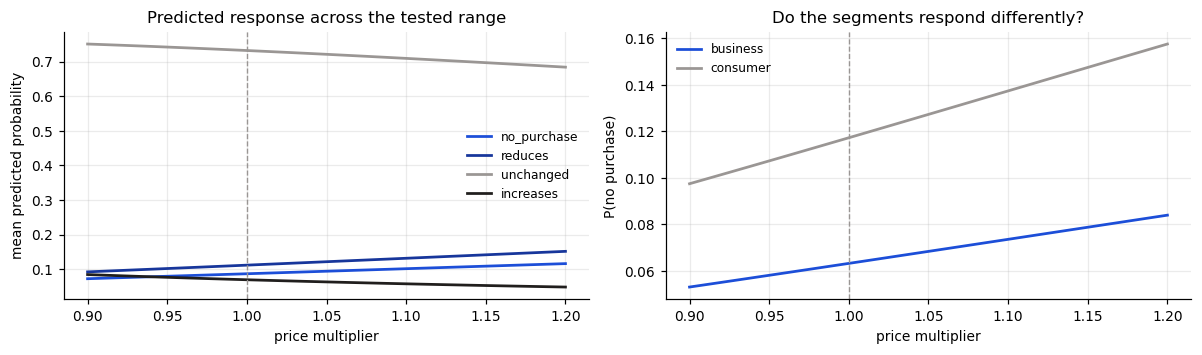

P(no purchase) swing across the range — business +0.0309, consumer +0.0601
Consumer should swing wider. If it does not, the selective-increase premise fails.

Observed no-purchase rate by segment and price (all trips)
price_multiplier   0.90   0.95   1.00   1.10   1.20
is_business                                        
False             0.091  0.116  0.118  0.165  0.205
True              0.059  0.063  0.067  0.080  0.100


In [8]:
GRID = np.round(np.linspace(0.90, 1.20, 25), 4)  # 25 points, 1.25pp apart, endpoints included exactly
SWEEP_SIGN = {"no_purchase": +1, "reduces": +1, "unchanged": -1, "increases": -1}

sweep = pd.DataFrame(
    [dict(zip(CLASSES, raw_score(X[te], trips[te], m).mean(axis=0)), price_multiplier=m)
     for m in GRID]).set_index("price_multiplier")
print(sweep.iloc[::4].round(4).to_string())

viol = {c: int(((sweep[c].diff().dropna()) * SWEEP_SIGN[c] < -1e-9).sum()) for c in CLASSES}
flat = {c: int((sweep[c].diff().abs().dropna() < 1e-9).sum()) for c in CLASSES}
print(f"\nMonotonicity violations : {viol}")
print(f"Flat steps (staircase)  : {flat}")

i_np = IDX["no_purchase"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
for c, col in zip(CLASSES, [ACCENT, "#17369b", MUTED, INK]):
    axes[0].plot(sweep.index, sweep[c], label=c, color=col, linewidth=1.8)
axes[0].axvline(1.0, color=MUTED, linestyle="--", linewidth=0.9)
axes[0].set_xlabel("price multiplier")
axes[0].set_ylabel("mean predicted probability")
axes[0].set_title("Predicted response across the tested range")
axes[0].legend(frameon=False, fontsize=8)

spans = {}
for seg, lbl, col in [(1, "business", ACCENT), (0, "consumer", MUTED)]:
    m = trips[te]["is_business"].to_numpy().astype(int) == seg
    curve = [raw_score(X[te][m], trips[te][m], p)[:, i_np].mean() for p in GRID]
    spans[lbl] = curve[-1] - curve[0]
    axes[1].plot(GRID, curve, color=col, linewidth=1.8, label=lbl)
axes[1].axvline(1.0, color=MUTED, linestyle="--", linewidth=0.9)
axes[1].set_xlabel("price multiplier")
axes[1].set_ylabel("P(no purchase)")
axes[1].set_title("Do the segments respond differently?")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f"P(no purchase) swing across the range — business {spans['business']:+.4f}, "
      f"consumer {spans['consumer']:+.4f}")
print("Consumer should swing wider. If it does not, the selective-increase premise fails.")

# The raw data's own answer, for comparison
raw_cmp = (trips.assign(np_flag=(trips.y == "no_purchase").astype(float))
           .pivot_table(index="is_business", columns="price_multiplier", values="np_flag"))
print("\nObserved no-purchase rate by segment and price (all trips)")
print(raw_cmp.round(3).to_string())

### 6.2 Regional price holdout — the gate

The temporal split cannot validate the price response, so hold out a **region**. Refit both stages with all APAC trips removed, then predict APAC trips during the market test — at elevated prices the model never saw for that region.

This is the check that matters most, because it tests the assumption the simulation is built on: that a price effect estimated on part of the book applies to the rest of it.

**If the model under-predicts the response, the revenue case is optimistic** — it will understate the damage from a price rise and make the +20% ceiling look safer than it is. The ratio computed below is exported so notebook 05 can bracket the simulation rather than pretend the miss is not there.

In [9]:
is_apac = (trips["region"] == "apac").to_numpy()
h_tr = tr & ~is_apac
h_s1 = h_tr & (trips["price_multiplier"] == 1.0).to_numpy()
h_te = is_apac & trips["month"].between(8, 15).to_numpy()

g_h = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06, max_leaf_nodes=31,
                                     min_samples_leaf=40, l2_regularization=1.0,
                                     early_stopping=True, validation_fraction=0.15,
                                     random_state=0).fit(X[h_s1], y[h_s1])
ord_h = [list(g_h.classes_).index(c) for c in CLASSES]


def s1_h(Xf):
    P = np.clip(g_h.predict_proba(Xf)[:, ord_h], 1e-6, None)
    return P / P.sum(axis=1, keepdims=True)


res_h = minimize(nll, np.zeros(9),
                 args=(np.log(s1_h(X[h_tr])), price_design(trips[h_tr]), yi[h_tr]),
                 method="L-BFGS-B", bounds=bounds, options={"maxiter": 500})
B_h = res_h.x.reshape(len(FIT_CLASSES), len(TERMS))

eta_h = np.log(s1_h(X[h_te]))
Z_h = price_design(trips[h_te])
for k, c in enumerate(FIT_CLASSES):
    eta_h[:, IDX[c]] += Z_h @ B_h[k]
P_h = softmax(eta_h)

cmp = (pd.DataFrame({"price": trips.loc[h_te, "price_multiplier"].to_numpy(),
                     "predicted": P_h[:, i_np],
                     "observed": (y[h_te] == "no_purchase").astype(float)})
       .groupby("price").agg(trips=("observed", "size"),
                             predicted=("predicted", "mean"),
                             observed=("observed", "mean")).round(4))
cmp["error"] = (cmp["predicted"] - cmp["observed"]).round(4)
print("APAC during the market test, predicted by a model that never saw APAC\n")
print(cmp.to_string())

if len(cmp) >= 2:
    pred_slope = cmp["predicted"].iloc[-1] - cmp["predicted"].iloc[0]
    obs_slope = cmp["observed"].iloc[-1] - cmp["observed"].iloc[0]
    RESPONSE_RATIO = float(obs_slope / pred_slope) if abs(pred_slope) > 1e-9 else np.nan
    print(f"\nResponse slope across the held-out price levels")
    print(f"  predicted {pred_slope:+.4f}   observed {obs_slope:+.4f}")
    print(f"  observed / predicted = {RESPONSE_RATIO:.2f}x")
    if RESPONSE_RATIO > 1.25:
        print("\n  The model UNDER-states the price response out of region. The revenue")
        print("  case built on it is optimistic. Notebook 05 must run the price response")
        print(f"  scaled by 1.0 and by {RESPONSE_RATIO:.2f} to bracket the answer.")
    elif RESPONSE_RATIO < 0.8:
        print("\n  The model OVER-states the response out of region; the case is")
        print("  conservative. Bracket it the same way.")
    else:
        print("\n  The response transfers. Applying one price to the whole book is justified.")
else:
    RESPONSE_RATIO = np.nan
    print("\nToo few held-out price levels to estimate a slope.")

APAC during the market test, predicted by a model that never saw APAC

       trips  predicted  observed   error
price                                    
1.1     2353     0.0859    0.1181 -0.0322
1.2     2353     0.0948    0.1347 -0.0399

Response slope across the held-out price levels
  predicted +0.0089   observed +0.0166
  observed / predicted = 1.87x

  The model UNDER-states the price response out of region. The revenue
  case built on it is optimistic. Notebook 05 must run the price response
  scaled by 1.0 and by 1.87 to bracket the answer.


---
## 7 · Calibration

The simulation computes `Σ P(state) × revenue(state)`, consuming probabilities as **quantities**. If the model says 20% walk away and 12% do, every dollar downstream is wrong by that ratio and no accuracy metric reveals it.

Isotonic per class, fitted on months 16–19. The calib window is itself split in two: whether to use calibration at all (§8) is decided on a held-out slice of *calib*, never on test — deciding that on test data would let the final report and the modelling choice see the same rows. The production calibrator is then refit on the full calib window, and test (20–23) is reserved purely for reporting.

Calibration decision — held-out 30% of the calib window (not test)

                 raw  isotonic
no_purchase  0.08316   0.08319
reduces      0.09227   0.09224
unchanged    0.19604   0.19593
increases    0.06724   0.06714

Brier score by class on TEST — reporting only, not used for the USE_CAL decision above



                 raw  isotonic
no_purchase  0.08586   0.08579
reduces      0.09727   0.09735
unchanged    0.19686   0.19635
increases    0.06159   0.06141

Mean predicted vs observed rate
             observed     raw  isotonic
no_purchase    0.0955  0.0871    0.0883
reduces        0.1107  0.1121    0.1142
unchanged      0.7282  0.7317    0.7267
increases      0.0656  0.0691    0.0708


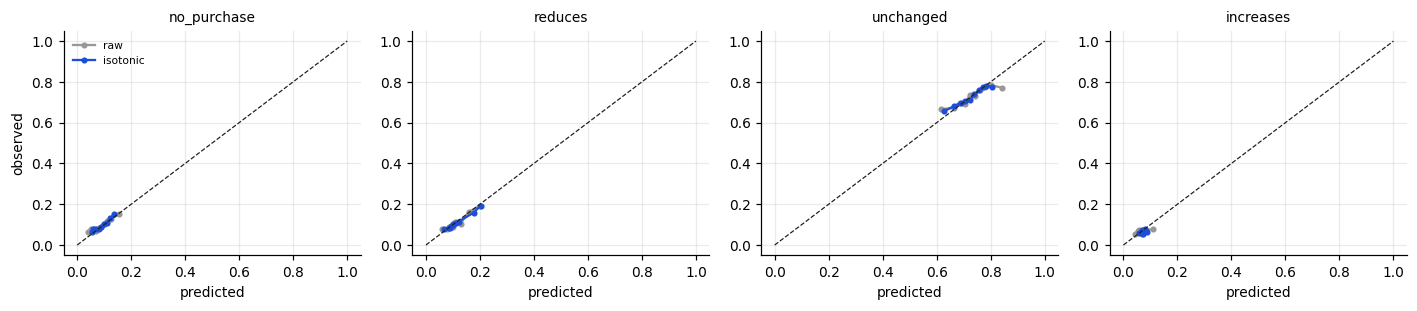

Caution: isotonic is fitted at observed prices. Applying it to a counterfactual
price assumes the correction does not itself depend on price — defensible over a
30-point range, and §6.2 is the check on the underlying response.


In [10]:
def brier_by_class(P, yv):
    return pd.Series({c: brier_score_loss((yv == c).astype(int), P[:, i])
                      for i, c in enumerate(CLASSES)})


def _calibrate_with(cals, P):
    Q = np.clip(np.column_stack([cals[c].predict(P[:, i]) for i, c in enumerate(CLASSES)]),
                1e-6, 1 - 1e-6)
    return Q / Q.sum(axis=1, keepdims=True)


# --- decide WHETHER to calibrate on a held-out slice of calib, not on test ---
# 70% of the calib window fits a decision-only isotonic; the remaining 30%
# scores raw vs. isotonic to make the USE_CAL call in §8. Test never enters
# this decision — see §8 for why that matters.
calib_rng = np.random.default_rng(0)
ca_pos = np.where(ca)[0]
perm = calib_rng.permutation(len(ca_pos))
n_fit = int(0.7 * len(ca_pos))
ca_fit, ca_eval = np.zeros_like(ca), np.zeros_like(ca)
ca_fit[ca_pos[perm[:n_fit]]] = True
ca_eval[ca_pos[perm[n_fit:]]] = True

CALS_decision = {c: IsotonicRegression(out_of_bounds="clip").fit(
                     raw_score(X[ca_fit], trips[ca_fit])[:, i], (y[ca_fit] == c).astype(int))
                 for i, c in enumerate(CLASSES)}
P_ca_eval = raw_score(X[ca_eval], trips[ca_eval])
decision_score = pd.DataFrame({
    "raw": brier_by_class(P_ca_eval, y[ca_eval]),
    "isotonic": brier_by_class(_calibrate_with(CALS_decision, P_ca_eval), y[ca_eval]),
})
print("Calibration decision — held-out 30% of the calib window (not test)\n")
print(decision_score.round(5).to_string())

# --- refit the PRODUCTION calibrator on the full calib window ---
# Now that whether to calibrate at all has been decided without touching test
# or the decision fold, use every calib row for the calibrator actually applied
# to test and to notebook 05.
P_ca = raw_score(X[ca], trips[ca])
CALS = {c: IsotonicRegression(out_of_bounds="clip").fit(P_ca[:, i], (y[ca] == c).astype(int))
        for i, c in enumerate(CLASSES)}


def calibrate(P):
    return _calibrate_with(CALS, P)


P_te_cal = calibrate(P_te)
print("\nBrier score by class on TEST — reporting only, not used for the USE_CAL decision above\n")
print(pd.DataFrame({"raw": brier_by_class(P_te, y[te]),
                    "isotonic": brier_by_class(P_te_cal, y[te])}).round(5).to_string())
print("\nMean predicted vs observed rate")
print(pd.DataFrame({"observed": [(y[te] == c).mean() for c in CLASSES],
                    "raw": P_te.mean(0), "isotonic": P_te_cal.mean(0)},
                   index=CLASSES).round(4).to_string())

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for i, (c, ax) in enumerate(zip(CLASSES, axes)):
    for P, lbl, col in [(P_te, "raw", MUTED), (P_te_cal, "isotonic", ACCENT)]:
        try:
            frac, mp = calibration_curve((y[te] == c).astype(int), P[:, i],
                                         n_bins=10, strategy="quantile")
            ax.plot(mp, frac, marker="o", ms=3, label=lbl, color=col, linewidth=1.5)
        except ValueError:
            pass
    ax.plot([0, 1], [0, 1], color=INK, linestyle="--", linewidth=0.8)
    ax.set_title(c, fontsize=9)
    ax.set_xlabel("predicted")
    if i == 0:
        ax.set_ylabel("observed")
        ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

print("Caution: isotonic is fitted at observed prices. Applying it to a counterfactual")
print("price assumes the correction does not itself depend on price — defensible over a")
print("30-point range, and §6.2 is the check on the underlying response.")

---
## 8 · The production scorer

In [11]:
cand = {"raw": P_te, "isotonic": P_te_cal}
score = pd.DataFrame({
    k: {"log loss": LL(y[te], P),
        "mean Brier": brier_by_class(P, y[te]).mean(),
        "aggregate prob error": np.abs(P.mean(0) - np.array([(y[te] == c).mean() for c in CLASSES])).sum(),
        "mean AUC": np.mean([roc_auc_score((y[te] == c).astype(int), P[:, i])
                             for i, c in enumerate(CLASSES)])}
    for k, P in cand.items()}).T.round(5)
print("Test-set metrics — reporting only. USE_CAL below was decided in §7 on a")
print("held-out slice of the calib window, before test was ever scored.\n")
print(score.to_string())
print(f"\nbase-rate log loss benchmark: {BASE_LL:.4f}")

USE_CAL = bool(decision_score["isotonic"].mean() <= decision_score["raw"].mean())
print(f"Using calibration: {USE_CAL}")


def score_trips(Xf, df, mult=None, response_scale=1.0):
    """Production interface. `mult` re-prices the book; `response_scale` stretches
    the price response, for the §6.2 bracketing that notebook 05 needs."""
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += response_scale * (Z @ B[k])
    P = softmax(eta)
    return calibrate(P) if USE_CAL else P


print("\nSanity: the test set at three prices")
for m in [0.90, 1.00, 1.20]:
    p = score_trips(X[te], trips[te], m).mean(0)
    print(f"  x{m:.2f}  " + "  ".join(f"{c}={v:.4f}" for c, v in zip(CLASSES, p)))

Test-set metrics — reporting only. USE_CAL below was decided in §7 on a
held-out slice of the calib window, before test was ever scored.

          log loss  mean Brier  aggregate prob error  mean AUC
raw        0.87202     0.11039               0.01681   0.56242
isotonic   0.87105     0.11022               0.01734   0.56119

base-rate log loss benchmark: 0.8804
Using calibration: True

Sanity: the test set at three prices
  x0.90  no_purchase=0.0779  reduces=0.0981  unchanged=0.7466  increases=0.0774


  x1.00  no_purchase=0.0880  reduces=0.1135  unchanged=0.7275  increases=0.0710
  x1.20  no_purchase=0.1091  reduces=0.1725  unchanged=0.6612  increases=0.0572


---
## 9 · Did the model recover the latent sensitivity?

The check real data can never offer. Each account's **model-implied sensitivity** is how far its predicted no-purchase probability moves between −10% and +20%, built purely from features. Compare against the sensitivity the generator used.

**The direction matters more than the magnitude.** A positive Spearman with a downward decile slope means the model found the mechanism. A *negative* correlation — which the previous version produced — means it is systematically identifying the wrong customers as sensitive, and any segmentation built on it would target exactly the wrong group.

One honest confound to keep in view: the generator ties sensitivity to travel frequency, so business accounts are both insensitive *and* frequent. The model sees frequency, not sensitivity.

Spearman, model-implied vs true sensitivity: +0.444
Positive = the model ranks sensitivity correctly. Negative = inverted.

Model-implied response by TRUE decile (0 = most sensitive)
                    accounts  mean_implied
sensitivity_decile                        
0                        688        0.0485
1                        761        0.0505
2                        732        0.0479
3                        772        0.0448
4                        845        0.0440
5                        932        0.0446
6                        987        0.0419
7                       1286        0.0316
8                       1857        0.0237
9                       2484        0.0204

Most sensitive decile responds 2.38x the least sensitive.
Above 1 is correct. Below 1 means the ranking is inverted.


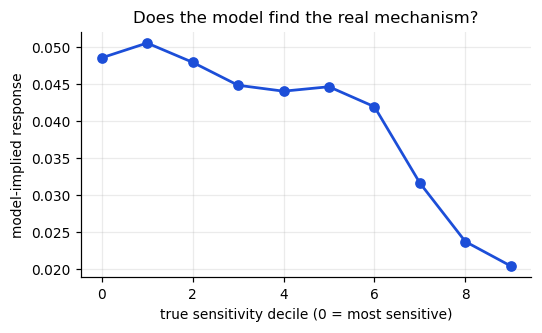

In [12]:
lo = score_trips(X[te], trips[te], 0.90)[:, i_np]
hi = score_trips(X[te], trips[te], 1.20)[:, i_np]
implied = (pd.DataFrame({"account_id": trips.loc[te, "account_id"].to_numpy(),
                         "implied": hi - lo})
           .groupby("account_id")["implied"].mean().reset_index())
chk = implied.merge(ground_truth, on="account_id")

rho = chk["implied"].corr(-chk["price_sensitivity"], method="spearman")
print(f"Spearman, model-implied vs true sensitivity: {rho:+.3f}")
print("Positive = the model ranks sensitivity correctly. Negative = inverted.\n")

by_dec = chk.groupby("sensitivity_decile").agg(accounts=("account_id", "size"),
                                               mean_implied=("implied", "mean")).round(4)
print("Model-implied response by TRUE decile (0 = most sensitive)")
print(by_dec.to_string())

lo_d, hi_d = by_dec["mean_implied"].iloc[0], by_dec["mean_implied"].iloc[-1]
print(f"\nMost sensitive decile responds {lo_d / max(hi_d, 1e-9):.2f}x the least sensitive.")
print("Above 1 is correct. Below 1 means the ranking is inverted.")

fig, ax = plt.subplots(figsize=(5, 3.1))
ax.plot(by_dec.index, by_dec["mean_implied"], marker="o", color=ACCENT, linewidth=1.8)
ax.set_xlabel("true sensitivity decile (0 = most sensitive)")
ax.set_ylabel("model-implied response")
ax.set_title("Does the model find the real mechanism?")
plt.tight_layout()
plt.show()

---
## 10 · Departure: the rare, expensive state

`no_purchase` pools two very different outcomes. Substituting an eSIM costs one trip's pass revenue. Leaving costs the whole relationship across every product — and it lands outside the roaming P&L entirely, which is why it is easy for a roaming-only analysis to ignore.

Modelled at the **account** level, where the evidence lives. Two things to say plainly rather than tune away: the model will be weak because a few hundred events cannot support much, and the simulation must carry a **range** rather than a point estimate. The bootstrap sizes that range.

In [13]:
acct = (trips.groupby("account_id")
        .agg(n_trips=("trip_id", "size"), avg_days=("days_traveled", "mean"),
             avg_party=("lines_traveling", "mean"), avg_price=("price_multiplier", "mean"),
             max_price=("price_multiplier", "max"),
             no_purchase_rate=("days_bought", lambda s: (s == 0).mean()),
             avg_ease=("substitute_ease", "mean"), departed=("account_lost", "max"),
             last_month=("month", "max"))
        .reset_index()
        .merge(accounts[["account_id", "is_business", "lines_on_account",
                         "tenure_months", "plan_tier"]], on="account_id"))
acct["premium"] = (acct["plan_tier"] == "premium").astype(int)
print(f"Departures: {int(acct.departed.sum()):,} of {len(acct):,} accounts "
      f"({acct.departed.mean():.3%})")

acols = ["n_trips", "avg_days", "avg_party", "avg_price", "max_price", "no_purchase_rate",
         "avg_ease", "is_business", "lines_on_account", "tenure_months", "premium"]
a_tr = (acct["last_month"] <= 19).to_numpy()
a_te = ~a_tr

pos = acct.loc[a_tr, "departed"].mean()
w = np.where(acct.loc[a_tr, "departed"] == 1, 0.5 / max(pos, 1e-9), 0.5 / (1 - pos))
dep = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                     min_samples_leaf=30, random_state=0)
dep.fit(acct.loc[a_tr, acols], acct.loc[a_tr, "departed"], sample_weight=w)

p_dep = dep.predict_proba(acct.loc[a_te, acols])[:, 1]
actual = acct.loc[a_te, "departed"].to_numpy()
if actual.sum() >= 10:
    print(f"\nAUC (test accounts): {roc_auc_score(actual, p_dep):.3f}   — 0.5 is no signal")
    q = pd.qcut(p_dep, 5, labels=False, duplicates="drop")
    lift = pd.DataFrame({"q": q, "actual": actual}).groupby("q")["actual"].agg(["size", "mean"])
    print("\nObserved departure rate by predicted-risk quintile")
    print(lift.round(4).to_string())
else:
    print(f"\nOnly {int(actual.sum())} departures in the test window — cannot validate.")

rng = np.random.default_rng(11)
d = acct["departed"].to_numpy()
boot = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(400)]
DEP_LO, DEP_HI = (float(v) for v in np.percentile(boot, [2.5, 97.5]))
print(f"\nDeparture rate, 95% bootstrap interval: {DEP_LO:.4%} to {DEP_HI:.4%}")
print(f"A {DEP_HI / max(DEP_LO, 1e-12):.1f}x spread — notebook 05 samples across it.")

Departures: 224 of 29,312 accounts (0.764%)



AUC (test accounts): 0.688   — 0.5 is no signal

Observed departure rate by predicted-risk quintile
   size    mean
q              
0  8704  0.0051
1   383  0.0679
2  2257  0.0235

Departure rate, 95% bootstrap interval: 0.6687% to 0.8734%
A 1.3x spread — notebook 05 samples across it.


---
## 11 · Export

In [14]:
P_all = score_trips(X, trips)
scored = trips[["trip_id", "account_id", "month", "region", "is_business",
                "lines_traveling", "days_traveled", "price_multiplier", "y"]].copy()
for i, c in enumerate(CLASSES):
    scored[f"p_{c}"] = P_all[:, i]
scored["slice"] = np.select([tr, ca, te], ["train", "calib", "test"], default="?")

# Per-account price response — what notebook 06 clusters on
curves = {f"p_np_{m:.2f}": score_trips(X, trips, m)[:, i_np] for m in [0.90, 1.00, 1.10, 1.20]}
resp = pd.DataFrame({"account_id": trips["account_id"].to_numpy(), **curves}) \
         .groupby("account_id").mean().reset_index()
resp["response_span"] = resp["p_np_1.20"] - resp["p_np_0.90"]

acct_risk = acct[["account_id"]].copy()
acct_risk["p_depart"] = dep.predict_proba(acct[acols])[:, 1]

meta = pd.DataFrame({
    "key": ["day_thresh", "use_calibration", "departure_lo", "departure_hi",
            "response_ratio", "base_log_loss", "test_log_loss"],
    "value": [DAY_THRESH, int(USE_CAL), DEP_LO, DEP_HI,
              RESPONSE_RATIO, BASE_LL, LL(y[te], P_te_cal if USE_CAL else P_te)],
})
print(meta.to_string(index=False))

FMT = "parquet"
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = "csv"
        print("\npyarrow/fastparquet not found, writing CSV instead.")

print()
for df, name in [(scored, "scored_trips"), (resp, "account_price_response"),
                 (acct_risk, "account_departure_risk"),
                 (sweep.reset_index(), "price_sweep"), (meta, "model_meta")]:
    path = DATA / f"{name}.{FMT}"
    df.to_parquet(path, index=False) if FMT == "parquet" else df.to_csv(path, index=False)
    print(f"  {path.name:32s} {len(df):>8,} rows")

            key    value
     day_thresh 0.700000
use_calibration 1.000000
   departure_lo 0.006687
   departure_hi 0.008734
 response_ratio 1.865169
  base_log_loss 0.880435
  test_log_loss 0.871055

  scored_trips.parquet               94,440 rows
  account_price_response.parquet     29,312 rows
  account_departure_risk.parquet     29,312 rows
  price_sweep.parquet                    25 rows
  model_meta.parquet                      7 rows


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Price effect survives controls | §4 | The response is real, not composition |
| Trees discriminate between accounts | §5 | AUC above 0.5 per class, `increases` excepted by design |
| Stage-2 coefficients match §4 | §6 | Stage 2 is measuring price, not absorbing something else |
| Net sign correct on every row | §6 | Not just the base coefficient — the effect each trip actually faces |
| Smooth, monotone price curve | §6.1 | Simulation curves will be defensible |
| Response transfer measured | §6.2 | Quantified as a ratio, exported to bracket the simulation |
| Probabilities calibrated | §7–8 | Expected-revenue arithmetic is sound |
| Mechanism recovered, right direction | §9 | Segmentation in 06 targets the right customers |
| Departure rate genuinely uncertain | §10 | Enters the simulation as a bootstrapped range |

### Three defects this version fixes

1. **A column-permutation bug in log loss.** `sklearn.log_loss` binarises `labels` in sorted order regardless of the order passed, so a matrix in `CLASSES` order was scored permuted. Every log loss in the previous versions was wrong — reported as roughly three times the base rate when the model was near it. All log losses now route through one guarded helper.
2. **A collinear price interaction.** `substitute_ease` is a lookup from `region`, so interacting it with price split the price effect arbitrarily: `log_price` +3.2 against `lp × ease` −4.5 gave a *net negative* price effect for high-ease regions. §2 now audits for it before modelling.
3. **Sign enforcement on the wrong quantity.** Checking base coefficients passed while the net effect per row was inverted for most of the book. The check now runs on the net effect each trip actually faces, and refits without interactions if any material share is wrong-signed.

4. **Stage 1 absorbing the price effect.** Region plus month let it learn the region x month market test, so stage-2 coefficients came out at a third of the identified value and the hybrid scored identically to stage 1 alone. Stage 1 now trains on standard-price trips only.

The offset is also now a real offset — stage 1's log-probabilities pinned at coefficient 1 rather than passed as features the logit could rescale to 2.58.

### Carry into notebook 05

1. **`score_trips(X, df, mult, response_scale)`** is the interface. Pass a scalar `mult` to re-price the book.
2. **Bracket with `response_scale`.** If §6.2 found the response under-stated, run the simulation at 1.0 and at the measured ratio and report both. An unbracketed answer overstates the safety of a price rise.
3. **Draw the macro shock once per iteration**, applied to every account. Independent draws understate the spread and report confidence the analysis has not earned.
4. **Sample the departure rate** between `departure_lo` and `departure_hi`.
5. **Expect the +20% cap to bind.** The panel is net inelastic across the range, so revenue is still climbing at the ceiling. Say plainly that the constraint chose +20%, not the model.

### Next

`04_magnitude_model.ipynb` — conditional day and line counts for `reduces` and `increases`, fitted only on trips in those states, so expected revenue has a size to multiply by and not just a direction.